# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [2]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df


Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [6]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# YOUR CODE BELOW

df["pct_change"] = (
    (df["attend_h1_2026"] - df["attend_h1_2025"])
    / df["attend_h1_2025"]
    * 100
)
display(df)

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]
print(f"Largest fall: Triage {largest_fall['triage']} ({largest_fall['triage_name']}), {largest_fall['pct_change']:.2f}%")
print(f"Largest rise: Triage {largest_rise['triage']} ({largest_rise['triage_name']}), {largest_rise['pct_change']:.2f}%")

triage_45 = df[df["triage"].isin([4, 5])]
attend_45_2025 = triage_45["attend_h1_2025"].sum()
attend_45_2026 = triage_45["attend_h1_2026"].sum()
pct_change_45 = (attend_45_2026 - attend_45_2025) / attend_45_2025 * 100
print(f"Triage 4+5 combined: {attend_45_2025:,} -> {attend_45_2026:,} ({pct_change_45:.2f}%)")

,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


Largest fall: Triage 5 (Non-urgent), -20.00%
Largest rise: Triage 1 (Critical), 5.00%
Triage 4+5 combined: 507,480 -> 456,732 (-10.00%)


In [13]:
# Task 1 note
task1_note = """
Triage 1–2 mainly rose, with Critical up 5.00% and Emergency up 5.00%; triage 4–5 fell, down 10.00% combined. This pattern is consistent with lower-urgency attendances decreasing while critical and emergency attendances are protected.
"""
print(task1_note)



Triage 1–2 mainly rose, with Critical up 5.00% and Emergency up 5.00%; triage 4–5 fell, down 10.00% combined. This pattern is consistent with lower-urgency attendances decreasing while critical and emergency attendances are protected.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


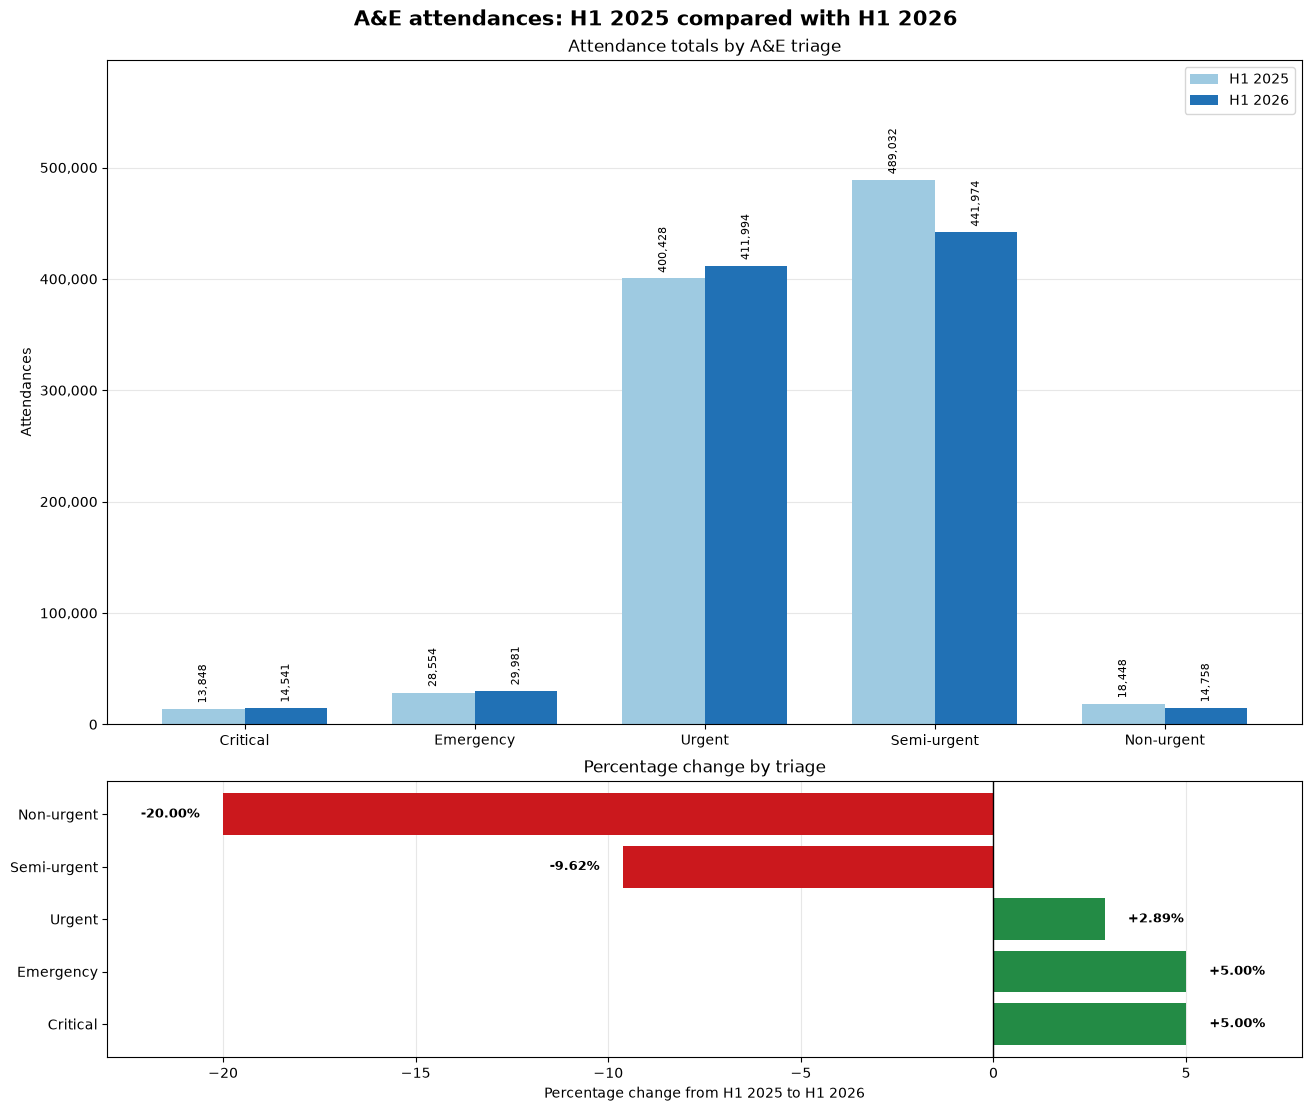

In [7]:
# Task 2 — grouped bar chart with clearer labels and a separate percentage-change panel
#
# Input: df, containing triage names, H1 2025 attendances,
#        H1 2026 attendances, and pct_change from Task 1.
# Process: Create a grouped attendance chart and a separate horizontal
#          percentage-change chart so labels do not overlap.
# Output: One figure with attendance numbers and readable percentage changes.

positions = list(range(len(df)))
bar_width = 0.36

fig, (attendance_ax, change_ax) = plt.subplots(
    2,
    1,
    figsize=(13, 11),
    gridspec_kw={"height_ratios": [2.4, 1]},
    constrained_layout=True,
)

bars_2025_updated = attendance_ax.bar(
    [position - bar_width / 2 for position in positions],
    df["attend_h1_2025"],
    width=bar_width,
    label="H1 2025",
    color="#9ecae1",
)
bars_2026_updated = attendance_ax.bar(
    [position + bar_width / 2 for position in positions],
    df["attend_h1_2026"],
    width=bar_width,
    label="H1 2026",
    color="#2171b5",
)

labels_2025 = [f"{value:,}" for value in df["attend_h1_2025"]]
labels_2026 = [f"{value:,}" for value in df["attend_h1_2026"]]

attendance_ax.bar_label(
    bars_2025_updated,
    labels=labels_2025,
    padding=4,
    rotation=90,
    fontsize=8,
)
attendance_ax.bar_label(
    bars_2026_updated,
    labels=labels_2026,
    padding=4,
    rotation=90,
    fontsize=8,
)

attendance_ax.set_ylim(
    0,
    df[["attend_h1_2025", "attend_h1_2026"]].to_numpy().max() * 1.22,
)
attendance_ax.set_xticks(positions, df["triage_name"])
attendance_ax.set_ylabel("Attendances")
attendance_ax.set_title("Attendance totals by A&E triage")
attendance_ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"{int(value):,}")
)
attendance_ax.grid(axis="y", alpha=0.3)
attendance_ax.set_axisbelow(True)
attendance_ax.legend(loc="upper right")

change_bars = change_ax.barh(
    df["triage_name"],
    df["pct_change"],
    color=["#238b45" if value >= 0 else "#cb181d" for value in df["pct_change"]],
)
change_ax.axvline(0, color="black", linewidth=1)

for bar, change in zip(change_bars, df["pct_change"]):
    label_x = change + 0.6 if change >= 0 else change - 0.6
    label_alignment = "left" if change >= 0 else "right"
    change_ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{change:+.2f}%",
        va="center",
        ha=label_alignment,
        fontsize=9,
        fontweight="bold",
    )

change_ax.set_xlim(-23, 8)
change_ax.set_xlabel("Percentage change from H1 2025 to H1 2026")
change_ax.set_title("Percentage change by triage")
change_ax.grid(axis="x", alpha=0.3)
change_ax.set_axisbelow(True)

fig.suptitle(
    "A&E attendances: H1 2025 compared with H1 2026",
    fontsize=15,
    fontweight="bold",
)
plt.show()

## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [9]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
Triage 4 and 5 together recorded 507,480 attendances in H1 2025 and 
456,732 in H1 2026, a fall of 50,748, or 10.00%. 
This is a supporting point for the claim that lower-urgency A&E use decreased after the reform.
The chart also shows both groups fell: 
Semi-urgent decreased by 9.62%, 
while Non-urgent fell by 20.00% over the same six months.

3a GAP (1 point):
These figures compare H1 2025 with H1 2026,
so changes between those two periods could partly explain the observed decline.
There is no control group or clear evidence isolating fee reform from staffing, demand, seasonal, or policy changes.
Attendance totals also do not show whether patients delayed care, shifted to other services.
Or experienced different clinical outcomes after the reform.
"""

task3b = """
3b:
Overall, the evidence partially supports the claim. 
Triage 4+5 attendances fell by 10.00% combined, 
while the proportion of triage III patients seen within 30 minutes rose from 81.4% to 88.5% and mean waiting time declined from 23 to 20 minutes; 
these figures are consistent with lower-urgency demand falling and urgent-care flow improving. 
Critical and Emergency attendance counts each increased by about 5%, 
which suggests demand was maintained, 
but counts alone do not demonstrate that care quality or outcomes were protected. 
Because the comparison is before-and-after and has no control group,
it cannot establish that the fee reform caused these changes.
"""

print(task3a)
print("---")
print(task3b)


3a SUPPORT (1 point, cite a number):
Triage 4 and 5 together recorded 507,480 attendances in H1 2025 and 
456,732 in H1 2026, a fall of 50,748, or 10.00%. 
This is a supporting point for the claim that lower-urgency A&E use decreased after the reform.
The chart also shows both groups fell: 
Semi-urgent decreased by 9.62%, 
while Non-urgent fell by 20.00% over the same six months.

3a GAP (1 point):
These figures compare H1 2025 with H1 2026,
so changes between those two periods could partly explain the observed decline.
There is no control group or clear evidence isolating fee reform from staffing, demand, seasonal, or policy changes.
Attendance totals also do not show whether patients delayed care, shifted to other services.
Or experienced different clinical outcomes after the reform.

---

3b:
Overall, the evidence partially supports the claim. 
Triage 4+5 attendances fell by 10.00% combined, 
while the proportion of triage III patients seen within 30 minutes rose from 81.4% to 88.5

## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
